<a href="https://colab.research.google.com/github/mujtaba-mohiyuddin/ucb-traffic-sign-recognition/blob/main/UCB_20260830_Practical_Application_MNSIT_Dataset_Digit_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf  # only used here to conveniently load the MNIST dataset

# Load MNIST directly - no download/Kaggle setup needed
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", X_train_full.shape)
print("Training labels shape:", y_train_full.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


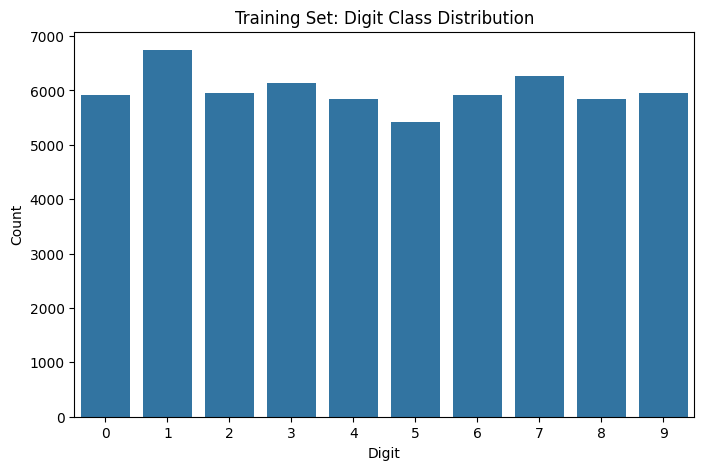

Digit 0: 5923 images (9.9%)
Digit 1: 6742 images (11.2%)
Digit 2: 5958 images (9.9%)
Digit 3: 6131 images (10.2%)
Digit 4: 5842 images (9.7%)
Digit 5: 5421 images (9.0%)
Digit 6: 5918 images (9.9%)
Digit 7: 6265 images (10.4%)
Digit 8: 5851 images (9.8%)
Digit 9: 5949 images (9.9%)


In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x=y_train_full)
plt.title("Training Set: Digit Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

unique, counts = np.unique(y_train_full, return_counts=True)
for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count} images ({count/len(y_train_full)*100:.1f}%)")

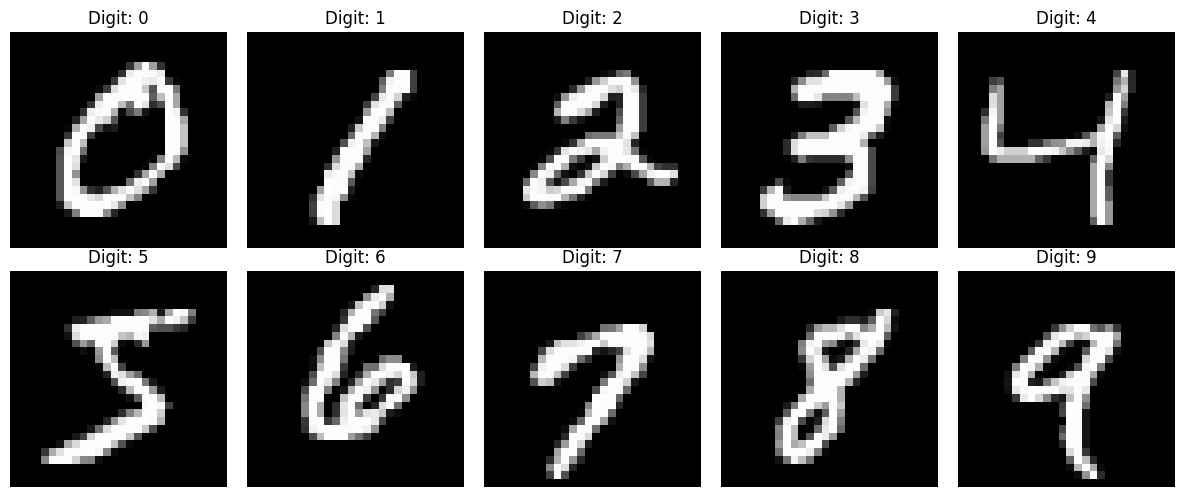

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(12,5))

for digit in range(10):
    idx = np.where(y_train_full == digit)[0][0]
    ax = axes[digit // 5, digit % 5]
    ax.imshow(X_train_full[idx], cmap="gray")
    ax.set_title(f"Digit: {digit}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# Normalize pixel values from 0-255 to 0-1
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Random Forest needs flat feature vectors, not 2D images
# Flatten each 28x28 image into a single row of 784 pixel values
X_train_full_flat = X_train_full.reshape(X_train_full.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Flattened training shape:", X_train_full_flat.shape)
print("Flattened test shape:", X_test_flat.shape)

Flattened training shape: (60000, 784)
Flattened test shape: (10000, 784)


In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full_flat, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test_flat.shape)

Train: (54000, 784) Val: (6000, 784) Test: (10000, 784)


In [13]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1  # use all available CPU cores
)

rf_model.fit(X_train, y_train)
print("Random Forest training complete")

Random Forest training complete


In [14]:
val_accuracy = rf_model.score(X_val, y_val)
print(f"Random Forest Validation Accuracy: {val_accuracy:.4f}")

Random Forest Validation Accuracy: 0.9652


In [15]:
y_pred = rf_model.predict(X_test_flat)
test_accuracy = (y_pred == y_test).mean()

print(f"Random Forest Test Accuracy: {test_accuracy:.4f}")
print(classification_report(y_test, y_pred))

Random Forest Test Accuracy: 0.9686
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.96      0.96      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.96      1028
           8       0.96      0.96      0.96       974
           9       0.95      0.95      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



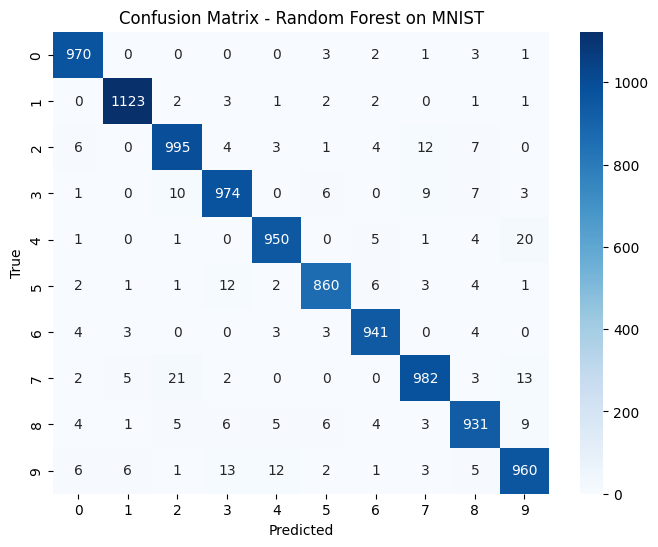

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest on MNIST")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

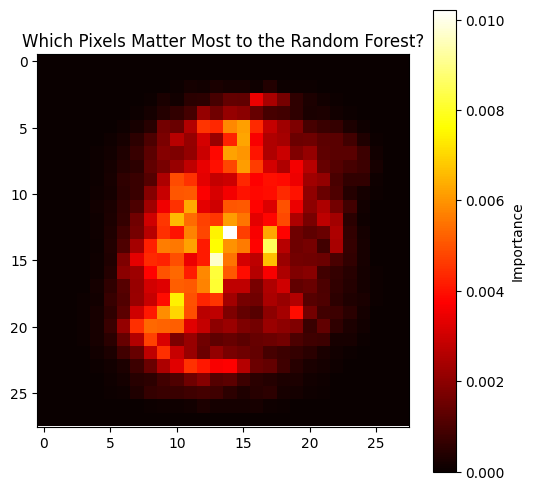

In [17]:
importances = rf_model.feature_importances_.reshape(28, 28)

plt.figure(figsize=(6,6))
plt.imshow(importances, cmap="hot")
plt.colorbar(label="Importance")
plt.title("Which Pixels Matter Most to the Random Forest?")
plt.show()

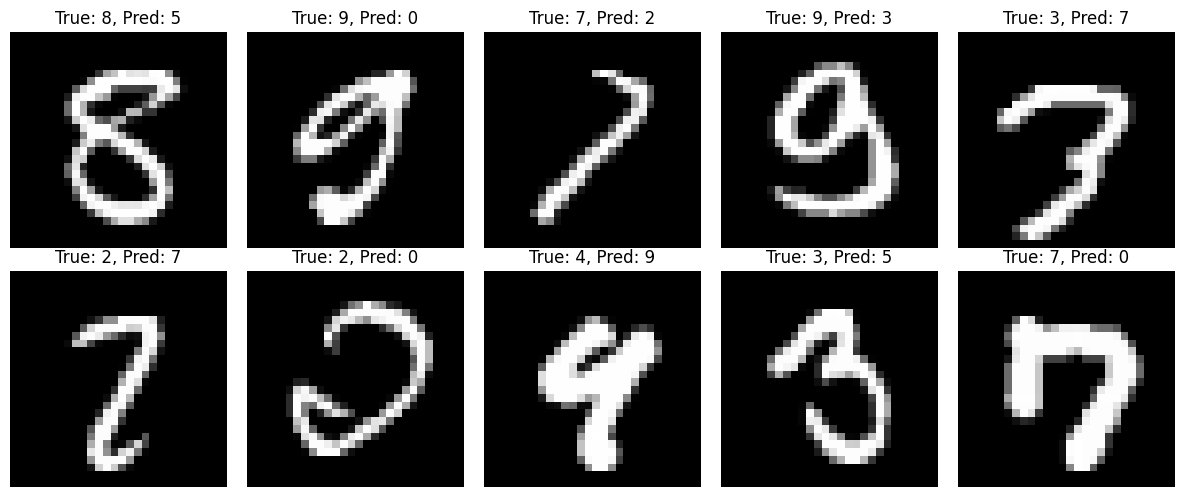

Total misclassified: 314 out of 10000 (3.14%)


In [18]:
misclassified_idx = np.where(y_pred != y_test)[0]
sample_idx = np.random.choice(misclassified_idx, 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12,5))
for ax, idx in zip(axes.flatten(), sample_idx):
    ax.imshow(X_test[idx].reshape(28,28), cmap="gray")
    ax.set_title(f"True: {y_test[idx]}, Pred: {y_pred[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_test)} ({len(misclassified_idx)/len(y_test)*100:.2f}%)")

n_estimators=10: Validation Accuracy=0.9402
n_estimators=50: Validation Accuracy=0.9642
n_estimators=100: Validation Accuracy=0.9652
n_estimators=200: Validation Accuracy=0.9672


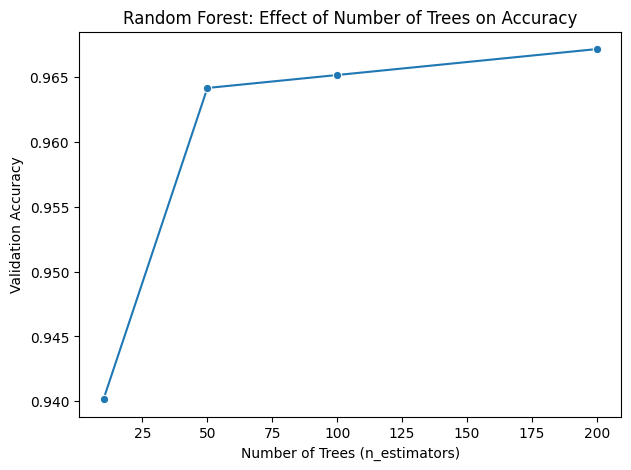

In [19]:
# A simple, non-deep-learning way to show iterative improvement
results = []
for n_trees in [10, 50, 100, 200]:
    model = RandomForestClassifier(n_estimators=n_trees, max_depth=20, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    acc = model.score(X_val, y_val)
    results.append({"n_estimators": n_trees, "val_accuracy": acc})
    print(f"n_estimators={n_trees}: Validation Accuracy={acc:.4f}")

results_df = pd.DataFrame(results)
plt.figure(figsize=(7,5))
sns.lineplot(x="n_estimators", y="val_accuracy", data=results_df, marker="o")
plt.title("Random Forest: Effect of Number of Trees on Accuracy")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Validation Accuracy")
plt.show()